In [11]:
import nibabel as nib
import numpy as np
import SimpleITK as sitk
import skimage
import pandas as pd
import os
import timeit
from pathlib import Path
import skimage.measure as measure
from skimage import morphology
from skimage.measure import regionprops
from scipy.ndimage import label, generate_binary_structure
import cv2
from totalsegmentator.python_api import totalsegmentator
import torch
from matplotlib import pyplot as plt
%matplotlib inline

In [12]:
def get_validation_dataset_paths():
    validation_root_path = os.path.join(os.getcwd(), r'Images\Validation Dataset')
    return {
        "KiTS19": os.path.join(validation_root_path, 'KiTS19'),
        "MSD_T10": os.path.join(validation_root_path, 'MSD_T10'),
    }

def find_validation_image(input_path):
    case_name = os.path.basename(input_path)

    if case_name.startswith('case_'):
        f_img = os.path.join(input_path, 'imaging.nii.gz')
    else:
        f_img = os.path.join(input_path, f'{case_name}.nii.gz')

    if not os.path.exists(f_img):
        raise FileNotFoundError(f"Expected validation image not found: {f_img}")

    return f_img

def find_validation_ground_truth(input_path):
    case_name = os.path.basename(input_path)

    if case_name.startswith('case_'):
        f_gt = os.path.join(input_path, f'dataset4_{case_name}_mask_4label.nii.gz')
    else:
        f_gt = os.path.join(input_path, f'dataset3_{case_name}_mask_4label.nii.gz')

    if not os.path.exists(f_gt):
        raise FileNotFoundError(f"Expected validation ground truth not found: {f_gt}")

    return f_gt

# Description: check if spacing is isotropic at a specified target value
def check_spacing(spacing, target=1.5, tol=1e-2):
    return all(abs(s - target) <= tol for s in spacing)

# Description: resample a 3D image to isotropic voxel spacing
def resample_to_isotropic(image, target_spacing=1.5, interpolator=sitk.sitkLinear):
    # Resample all images to 1.5 mm isotropic resolution
    original_spacing = image.GetSpacing()
    original_size = image.GetSize()
    new_spacing = (target_spacing, target_spacing, target_spacing)
    new_size = [
        int(round(original_size[i] * (original_spacing[i] / new_spacing[i])))
        for i in range(3)
    ]
    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(new_spacing)
    resample.SetSize(new_size)
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(image.GetOrigin())
    resample.SetInterpolator(interpolator)
    return resample.Execute(image)

def resample_to_reference(image, reference_image, interpolator=sitk.sitkNearestNeighbor):
    resample = sitk.ResampleImageFilter()
    resample.SetReferenceImage(reference_image)
    resample.SetInterpolator(interpolator)
    return resample.Execute(image)

def get_resampled_path(input_path, suffix="_resampled_1p5mm"):
    if input_path.endswith(".nii.gz"):
        return input_path[:-7] + f"{suffix}.nii.gz"
    if input_path.endswith(".nii"):
        return input_path[:-4] + f"{suffix}.nii.gz"
    raise RuntimeError(f"Accepted file format: NIfTI (.nii/.nii.gz): {input_path}")

def get_validation_workflow_inputs(input_path):
    image_path = find_validation_image(input_path)
    gt_path = find_validation_ground_truth(input_path)

    ct_nii = nib.load(image_path)
    spacing = ct_nii.header.get_zooms()[:3]
    print("Spacing (x, y, z):", spacing)

    if check_spacing(spacing, target=1.5, tol=1e-2):
        print("Spacing already 1.5 mm isotropic; skipping image resample.")
        workflow_image_path = image_path
        reference_image = sitk.ReadImage(workflow_image_path)
    else:
        workflow_image_path = get_resampled_path(image_path)
        if os.path.exists(workflow_image_path):
            print(f"Using existing resampled image: {workflow_image_path}")
            reference_image = sitk.ReadImage(workflow_image_path)
        else:
            print("Resampling image to 1.5 mm isotropic...")
            ct_sitk = sitk.ReadImage(image_path)
            ct_resampled = resample_to_isotropic(ct_sitk, target_spacing=1.5, interpolator=sitk.sitkLinear)
            sitk.WriteImage(ct_resampled, workflow_image_path)
            reference_image = ct_resampled

        ct_resampled_nii = nib.load(workflow_image_path)
        print("Resampled shape:", ct_resampled_nii.shape)
        print("Resampled spacing (x, y, z):", ct_resampled_nii.header.get_zooms()[:3])

    workflow_gt_path = get_resampled_path(gt_path)
    gt_nii = nib.load(gt_path)
    gt_spacing = gt_nii.header.get_zooms()[:3]

    if workflow_image_path == image_path and check_spacing(gt_spacing, target=1.5, tol=1e-2):
        workflow_gt_path = gt_path
        print("Ground truth spacing already 1.5 mm isotropic; skipping ground truth resample.")
    else:
        if os.path.exists(workflow_gt_path):
            print(f"Using existing resampled ground truth: {workflow_gt_path}")
        else:
            print("Resampling ground truth to match workflow image geometry...")
            gt_sitk = sitk.ReadImage(gt_path)
            gt_resampled = resample_to_reference(gt_sitk, reference_image, interpolator=sitk.sitkNearestNeighbor)
            sitk.WriteImage(gt_resampled, workflow_gt_path)

    return workflow_image_path, workflow_gt_path


def prepare_validation_ground_truth(input_path):
    # Ground truth labels: 2 = left hip, 3 = right hip
    _, f_gt = get_validation_workflow_inputs(input_path)
    gt_nii = nib.load(f_gt)
    gt_arr = gt_nii.get_fdata()

    right_gt = (gt_arr == 3).astype(np.uint8)
    left_gt = (gt_arr == 2).astype(np.uint8)

    right_nii = nib.Nifti1Image(right_gt, affine=gt_nii.affine, header=gt_nii.header)
    left_nii = nib.Nifti1Image(left_gt, affine=gt_nii.affine, header=gt_nii.header)

    nib.save(right_nii, os.path.join(input_path, 'hip_right_gt.nii.gz'))
    nib.save(left_nii, os.path.join(input_path, 'hip_left_gt.nii.gz'))

def _binary_threshold_np(img, low, high):
    arr = np.asarray(img)
    out = np.zeros(arr.shape, dtype=np.uint8)
    m = np.isfinite(arr)
    out[m] = ((arr[m] >= low) & (arr[m] <= high)).astype(np.uint8)
    return out

def _remove_small_objects_np(mask, min_size):
    lab = morphology.label(mask)
    cleaned = morphology.remove_small_objects(lab, min_size)
    return (cleaned > 0).astype(np.uint8)

def _floodfill_np(mask):
    arr = np.asarray(mask, dtype=np.uint8)
    h, w = arr.shape
    ff = arr.copy()
    m = np.zeros((h+2, w+2), np.uint8)
    cv2.floodFill(ff, m, (0,0), 255)
    inv = (cv2.bitwise_not(ff) > 0).astype(np.uint8)
    return inv

def _dilate_np(mask, kernel, it):
    m = np.asarray(mask, dtype=np.uint8)
    k = np.asarray(kernel, dtype=np.uint8)
    i = int(np.asarray(it, dtype=np.uint8))
    return cv2.dilate(m, k, iterations=i)

def _erode_np(mask, kernel, it):
    m = np.asarray(mask, dtype=np.uint8)
    k = np.asarray(kernel, dtype=np.uint8)
    i = int(np.asarray(it, dtype=np.uint8))
    return cv2.erode(m, k, iterations=i)
    
def clean_mask_hip(ct_arr, ct_cropped, hip_mask, n_classes=3, dilate_kernel=None, dilate_iters=1, erode_iters=1):
    if dilate_kernel is None:
        dilate_kernel = np.array([[0,1,0],[1,1,1],[0,1,0]], dtype=np.uint8)

    zdim = hip_mask.shape[0]
    refined_mask = (hip_mask > 0).astype(np.uint8)
    
    # Metrics holder for HU-based expansion
    added_voxels_records = np.zeros(zdim, dtype=np.int32)

    # Find inferior bound of acetabulum corresponding to 0.6 cm below the upper border of obturator foramen
    # The longest run of slices > 2 objects correspond to obturator foramen
    max_len = 0
    current_len = 0
    end_idx = -1
    for z in range(zdim):
        cleaned_slice = _remove_small_objects_np(hip_mask[z], min_size=100)
        _, count = label(cleaned_slice)
        if count >= 2:
            current_len += 1
            if current_len > max_len:
                max_len = current_len
                end_idx = z
        else:
            current_len = 0

    if max_len > 0:
        start_idx = end_idx - max_len + 1
        print(f"Longest run of slices with ≥2 objects: {max_len} slices (z={start_idx} to z={end_idx})")
        print(f"Most superior slice of obturator foramen: z={end_idx}")
    
        inferior_bound = max(end_idx - 3, 0)
        print(f"Inferior bound: z={inferior_bound}")
    else:
        print("Obturator foramen not detected -- falling back to most inferior non-empty slice.")
        
        inferior_bound = None
        for z in range(zdim):
            cleaned_slice = _remove_small_objects_np(hip_mask[z], min_size=100)
            if np.any(cleaned_slice):
                inferior_bound = z
                break

        if inferior_bound is None:
            print("Hip bone mask is empty -- returning original mask.")
            return refined_mask, None, None, added_voxels_records

        print(f"Inferior bound (fallback): z={inferior_bound}")

    # Find superior bound corresponding to 0.9 cm above the acetabular roof
    # The first slice with > 0.9 solidity corresponds to acetabular roof
    superior_bound = None
    for z in range(end_idx + 1, zdim):
        labeled, _ = label(hip_mask[z])
        props = regionprops(labeled)
        if props:
            largest_region = max(props, key=lambda r: r.area)
            solidity = largest_region.solidity
        else:
            solidity = 0.0

        if solidity > 0.9:
            superior_bound = z + 6
            if superior_bound >= zdim:
                superior_bound = zdim - 1
            print(f"Acetabular roof at slice {z}, setting superior bound = {superior_bound}")
            break

    if superior_bound is None:
        superior_bound = inferior_bound + 34
        if superior_bound >= zdim:
            superior_bound = zdim - 1
        print("No slice with solidity > 0.9 found. Forcing range to be 34.")

    # Sanity check: valid cleaning range should be within 4.2-6.0 cm
    cleaning_range = superior_bound - inferior_bound
    if cleaning_range < 28 or cleaning_range > 40:
        print(f"Warning: suspicious acetabular roof identification with {cleaning_range} slices of acetabulum. Forcing range to be 34.")
        superior_bound = inferior_bound + 34
        if superior_bound >= zdim:
            superior_bound = zdim - 1

    print(f"Cleaning range: z={inferior_bound} to z={superior_bound}")
    
    # Clean selected slices
    for i in range(inferior_bound, min(superior_bound + 1, zdim)):
        slice_crop = ct_cropped[i]
        slice_ct = ct_arr[i]

        # Apply binary thresholding
        mask_bi = _binary_threshold_np(slice_crop, low=150, high=np.inf)

        # HU-based expansion
        max_added_voxels = 40  # sanity cap per slice
        high_hu = slice_ct > 300
        labeled_high, num_high = label(high_hu.astype(np.uint8))
    
        if num_high > 0:
            touching_labels = np.unique(labeled_high[mask_bi.astype(bool)])
            touching_labels = touching_labels[touching_labels != 0]
    
            if touching_labels.size > 0:
                connected_high = np.isin(labeled_high, touching_labels)
                expanded_mask = mask_bi.astype(bool) | connected_high
                added_voxels = (np.count_nonzero(expanded_mask) - np.count_nonzero(mask_bi))
                
                # Record metric
                added_voxels_records[i] = int(added_voxels)
                
                if added_voxels <= max_added_voxels:
                    mask_exp = expanded_mask.astype(np.uint8)
                else:
                    print(
                        f"Slice {i}: HU-based expansion added {added_voxels} voxels "
                        f"(> {max_added_voxels}); reverting to mask after binary thresholding."
                    )
                    mask_exp = mask_bi
            else:
                mask_exp = mask_bi
        else:
            mask_exp = mask_bi
        mask_dil = _dilate_np(mask_exp, dilate_kernel, dilate_iters)
        mask_erod = _erode_np(mask_dil, dilate_kernel, erode_iters)
        mask_fill = _floodfill_np(mask_erod)
        refined_mask[i] = mask_fill
        
    # 3D connectivity: keep only the largest connected component
    structure = generate_binary_structure(3, 1)
    labeled_3d, num = label(refined_mask.astype(bool), structure=structure)
    print(f"3D connected components found: {num}")
    if num == 0:
        print("Warning: refined hip mask is empty after 3D labeling.")
        return refined_mask, inferior_bound, superior_bound, added_voxels_records
    
    counts = np.bincount(labeled_3d.ravel())
    counts[0] = 0
    
    largest_label = counts.argmax()
    refined_mask = (labeled_3d == largest_label).astype(np.uint8)
    return refined_mask, inferior_bound, superior_bound, added_voxels_records
    
def run_cleaning_workflow(input_path):
    # Load NIfTI file and get shape and affine
    nifti_path, _ = get_validation_workflow_inputs(input_path)
    output_path = input_path
    ct_nii = nib.load(nifti_path)
    shape = ct_nii.shape
    print("Shape:", shape)
    affine = ct_nii.affine
    spacing = tuple(abs(affine[i, i]) for i in range(3))
    print("Spacing (x, y, z):", spacing)
    
    # Convert to NumPy array and mandate orientation
    ct_arr_init = ct_nii.get_fdata()
    init_axcodes = nib.aff2axcodes(affine)
    print("Initial orientation:", init_axcodes)
    target_axcodes = ('L', 'P', 'S')
    ornt_init = nib.orientations.axcodes2ornt(init_axcodes)
    ornt_target = nib.orientations.axcodes2ornt(target_axcodes)
    ornt_transf = nib.orientations.ornt_transform(ornt_init, ornt_target)
    ct_arr_lps = nib.orientations.apply_orientation(ct_arr_init, ornt_transf)
    ct_arr = np.transpose(ct_arr_lps, axes=(2, 1, 0))
    
    # Run TotalSegmentator
    right_hip_pred = totalsegmentator(nifti_path, input_path, task="total", roi_subset=["hip_right"],  fast=False, ml=False, device="gpu", skip_saving=False)
    left_hip_pred  = totalsegmentator(nifti_path, input_path, task="total", roi_subset=["hip_left"],   fast=False, ml=False, device="gpu", skip_saving=False)
    # Get segmentation arrays
    right_hip_pred_arr_init = right_hip_pred.get_fdata()
    left_hip_pred_arr_init = left_hip_pred.get_fdata()
    # Correct orientation  
    right_hip_pred_arr_lps = nib.orientations.apply_orientation(right_hip_pred_arr_init, ornt_transf)
    left_hip_pred_arr_lps = nib.orientations.apply_orientation(left_hip_pred_arr_init, ornt_transf)
    # Transpose merged mask    
    right_hip_pred_arr_rev = np.transpose(right_hip_pred_arr_lps, axes=(2, 1, 0))
    left_hip_pred_arr_rev = np.transpose(left_hip_pred_arr_lps, axes=(2, 1, 0))
    # Create cropped image
    right_hip_cropped = np.where(right_hip_pred_arr_rev == 78, ct_arr, np.nan)
    left_hip_cropped = np.where(left_hip_pred_arr_rev == 77, ct_arr, np.nan)
    # Create binary mask
    right_hip_pred_arr_rev_bi = (right_hip_pred_arr_rev == 78).astype(np.uint8)
    left_hip_pred_arr_rev_bi  = (left_hip_pred_arr_rev  == 77).astype(np.uint8)
    # Run post-processing function
    print("\n=== Right hip | default morphological closing ===")
    right_hip_mask_cleaned, right_inf, right_sup, right_added_voxels = clean_mask_hip(ct_arr, right_hip_cropped, right_hip_pred_arr_rev_bi, 
                                           n_classes=3, dilate_kernel=None, dilate_iters=1, erode_iters=1)
    print("\n=== Left hip | default morphological closing ===")
    left_hip_mask_cleaned, left_inf, left_sup, left_added_voxels = clean_mask_hip(ct_arr, left_hip_cropped, left_hip_pred_arr_rev_bi,
                                          n_classes=3, dilate_kernel=None, dilate_iters=1, erode_iters=1)
    print("\n=== Right hip | fallback morphological closing ===")
    right_hip_mask_cleaned_fallback, _, _, _ = clean_mask_hip(ct_arr, right_hip_cropped, right_hip_pred_arr_rev_bi, 
                                                    n_classes=3, dilate_kernel=None, dilate_iters=3, erode_iters=3)
    print("\n=== Left hip | fallback morphological closing ===")
    left_hip_mask_cleaned_fallback, _, _, _ = clean_mask_hip(ct_arr, left_hip_cropped, left_hip_pred_arr_rev_bi,
                                                   n_classes=3, dilate_kernel=None, dilate_iters=3, erode_iters=3)
    
    # Identify slices where voxel count difference > 60 between the two morph close methods
    right_hip_voxel_count = np.count_nonzero(right_hip_mask_cleaned, axis=(1, 2)).astype(np.int32)
    right_hip_voxel_count_fallback = np.count_nonzero(right_hip_mask_cleaned_fallback, axis=(1, 2)).astype(np.int32)
    right_hip_voxel_count_diff = right_hip_voxel_count_fallback - right_hip_voxel_count
    right_hip_slices_to_replace = np.where(right_hip_voxel_count_diff > 60)[0]
    left_hip_voxel_count = np.count_nonzero(left_hip_mask_cleaned, axis=(1, 2)).astype(np.int32)
    left_hip_voxel_count_fallback = np.count_nonzero(left_hip_mask_cleaned_fallback, axis=(1, 2)).astype(np.int32)
    left_hip_voxel_count_diff = left_hip_voxel_count_fallback - left_hip_voxel_count
    left_hip_slices_to_replace = np.where(left_hip_voxel_count_diff > 60)[0]
    
    # Replace those slices to generate the processed mask
    right_hip_mask_cleaned_processed = right_hip_mask_cleaned.copy()
    left_hip_mask_cleaned_processed = left_hip_mask_cleaned.copy()
    right_hip_mask_cleaned_processed[right_hip_slices_to_replace] = \
        right_hip_mask_cleaned_fallback[right_hip_slices_to_replace]
    left_hip_mask_cleaned_processed[left_hip_slices_to_replace] = \
        left_hip_mask_cleaned_fallback[left_hip_slices_to_replace]    
    print(f"Replaced {len(right_hip_slices_to_replace)} slices for the right hip with fallback morphological closing.")
    print(f"Slices replaced: {right_hip_slices_to_replace.tolist()}")
    print(f"Replaced {len(left_hip_slices_to_replace)} slices for the left hip with fallback morphological closing.")
    print(f"Slices replaced: {left_hip_slices_to_replace.tolist()}")
    
    # Identify slices where voxel count difference < -10 or > 200 between the processed mask and the original mask
    right_hip_mask_cleaned_final = right_hip_mask_cleaned_processed.copy()
    left_hip_mask_cleaned_final = left_hip_mask_cleaned_processed.copy()
    right_hip_voxel_count_processed = np.count_nonzero(right_hip_mask_cleaned_processed, axis=(1, 2)).astype(np.int32)
    right_hip_voxel_count_original = np.count_nonzero(right_hip_pred_arr_rev, axis=(1, 2)).astype(np.int32)
    right_hip_voxel_count_diff_final = right_hip_voxel_count_original - right_hip_voxel_count_processed
    right_hip_slices_to_replace_final = np.where((right_hip_voxel_count_diff_final < -10) | (right_hip_voxel_count_diff_final > 200))[0]
    left_hip_voxel_count_processed = np.count_nonzero(left_hip_mask_cleaned_processed, axis=(1, 2)).astype(np.int32)
    left_hip_voxel_count_original = np.count_nonzero(left_hip_pred_arr_rev, axis=(1, 2)).astype(np.int32)
    left_hip_voxel_count_diff_final = left_hip_voxel_count_original - left_hip_voxel_count_processed
    left_hip_slices_to_replace_final = np.where((left_hip_voxel_count_diff_final < -10) | (left_hip_voxel_count_diff_final > 200))[0]
    
    # Replace those slices to generate the final mask
    right_hip_mask_cleaned_final[right_hip_slices_to_replace_final] = \
        right_hip_pred_arr_rev_bi[right_hip_slices_to_replace_final]
    left_hip_mask_cleaned_final[left_hip_slices_to_replace_final] = \
        left_hip_pred_arr_rev_bi[left_hip_slices_to_replace_final]
    print(f"Replaced {len(right_hip_slices_to_replace_final)} slices for the right hip with original segmentation.")
    print(f"Slices replaced: {right_hip_slices_to_replace_final.tolist()}")
    print(f"Replaced {len(left_hip_slices_to_replace_final)} slices for the left hip with original segmentation.")
    print(f"Slices replaced: {left_hip_slices_to_replace_final.tolist()}")

    # Transpose back
    right_hip_mask_cleaned_transposed = np.transpose(right_hip_mask_cleaned_final, (2, 1, 0))
    left_hip_mask_cleaned_transposed = np.transpose(left_hip_mask_cleaned_final, (2, 1, 0))
    # Reorient back
    ornt_transf_back = nib.orientations.ornt_transform(ornt_target, ornt_init)
    right_hip_mask_cleaned_ras = nib.orientations.apply_orientation(right_hip_mask_cleaned_transposed, ornt_transf_back)
    left_hip_mask_cleaned_ras = nib.orientations.apply_orientation(left_hip_mask_cleaned_transposed, ornt_transf_back)
    # Save cleaned mask as NIfTI file that matches the orientation of original input file
    right_hip_mask_cleaned_nii = nib.Nifti1Image(right_hip_mask_cleaned_ras, affine=ct_nii.affine, header=ct_nii.header)
    left_hip_mask_cleaned_nii = nib.Nifti1Image(left_hip_mask_cleaned_ras, affine=ct_nii.affine, header=ct_nii.header)
    # Save to disk
    nib.save(right_hip_mask_cleaned_nii, os.path.join(output_path, 'hip_right_cleaned.nii.gz'))
    nib.save(left_hip_mask_cleaned_nii, os.path.join(output_path, 'hip_left_cleaned.nii.gz'))
    
    return (
    right_hip_mask_cleaned,
    right_hip_mask_cleaned_fallback,
    right_hip_pred_arr_rev_bi,
    left_hip_mask_cleaned,
    left_hip_mask_cleaned_fallback,
    left_hip_pred_arr_rev_bi,
    right_added_voxels,
    left_added_voxels,
    right_inf,
    right_sup,
    left_inf,
    left_sup,
)    


In [13]:
def compute_voxel_count_diff(
    right_hip_mask_cleaned,
    right_hip_mask_cleaned_fallback,
    right_hip_pred_arr_rev_bi,
    left_hip_mask_cleaned,
    left_hip_mask_cleaned_fallback,
    left_hip_pred_arr_rev_bi,
    right_added_voxels=None,
    left_added_voxels=None,
    thresh_fallback_replace=60,
    thresh_orig_lower=-10,
    thresh_orig_upper=200,
):

    assert right_hip_mask_cleaned.shape == right_hip_mask_cleaned_fallback.shape == right_hip_pred_arr_rev_bi.shape
    assert left_hip_mask_cleaned.shape == left_hip_mask_cleaned_fallback.shape == left_hip_pred_arr_rev_bi.shape

    zdim = right_hip_mask_cleaned.shape[0]
    assert left_hip_mask_cleaned.shape[0] == zdim

    if right_added_voxels is None:
        right_added_voxels = np.zeros(zdim, dtype=np.int32)
    if left_added_voxels is None:
        left_added_voxels = np.zeros(zdim, dtype=np.int32)
    
    rows = []

    # Voxel count difference-based overrule: cleaned vs fallback
    right_cleaned_count = np.count_nonzero(right_hip_mask_cleaned, axis=(1, 2)).astype(np.int32)
    right_fallback_count = np.count_nonzero(right_hip_mask_cleaned_fallback, axis=(1, 2)).astype(np.int32)
    right_diff1 = right_fallback_count - right_cleaned_count
    right_replace_fallback = right_diff1 > thresh_fallback_replace
    left_cleaned_count = np.count_nonzero(left_hip_mask_cleaned, axis=(1, 2)).astype(np.int32)
    left_fallback_count = np.count_nonzero(left_hip_mask_cleaned_fallback, axis=(1, 2)).astype(np.int32)
    left_diff1 = left_fallback_count - left_cleaned_count
    left_replace_fallback = left_diff1 > thresh_fallback_replace
    right_hip_mask_processed = right_hip_mask_cleaned.copy()
    left_hip_mask_processed = left_hip_mask_cleaned.copy()
    right_hip_mask_processed[right_replace_fallback] = right_hip_mask_cleaned_fallback[right_replace_fallback]
    left_hip_mask_processed[left_replace_fallback] = left_hip_mask_cleaned_fallback[left_replace_fallback]

    # Voxel count difference-based overrule: processed vs original
    right_processed_count = np.count_nonzero(right_hip_mask_processed, axis=(1, 2)).astype(np.int32)
    right_original_count = np.count_nonzero(right_hip_pred_arr_rev_bi, axis=(1, 2)).astype(np.int32)
    right_diff2 = right_original_count - right_processed_count
    right_replace_original = (right_diff2 < thresh_orig_lower) | (right_diff2 > thresh_orig_upper)
    left_processed_count = np.count_nonzero(left_hip_mask_processed, axis=(1, 2)).astype(np.int32)
    left_original_count = np.count_nonzero(left_hip_pred_arr_rev_bi, axis=(1, 2)).astype(np.int32)
    left_diff2 = left_original_count - left_processed_count
    left_replace_original = (left_diff2 < thresh_orig_lower) | (left_diff2 > thresh_orig_upper)

    # Construct dataframe
    for z in range(zdim):
        rows.append({
            "side": "right",
            "slice_z": z,

            "count_cleaned": int(right_cleaned_count[z]),
            "count_fallback": int(right_fallback_count[z]),
            "diff_fallback_minus_cleaned": int(right_diff1[z]),
            "replaced_by_fallback": bool(right_replace_fallback[z]),

            "count_processed": int(right_processed_count[z]),
            "count_original": int(right_original_count[z]),
            "diff_original_minus_processed": int(right_diff2[z]),
            "replaced_by_original": bool(right_replace_original[z]),
            "added_voxels": int(right_added_voxels[z]),
        })

        rows.append({
            "side": "left",
            "slice_z": z,

            "count_cleaned": int(left_cleaned_count[z]),
            "count_fallback": int(left_fallback_count[z]),
            "diff_fallback_minus_cleaned": int(left_diff1[z]),
            "replaced_by_fallback": bool(left_replace_fallback[z]),

            "count_processed": int(left_processed_count[z]),
            "count_original": int(left_original_count[z]),
            "diff_original_minus_processed": int(left_diff2[z]),
            "replaced_by_original": bool(left_replace_original[z]),
            "added_voxels": int(left_added_voxels[z]),
        })

    df = pd.DataFrame(rows)
    return df

In [14]:
validation_dataset_paths = get_validation_dataset_paths()

for dataset_name, root_path in validation_dataset_paths.items():
    print(f"\n=== Validation dataset: {dataset_name} ===")

    for subfolder in sorted(os.listdir(root_path)):
        subfolder_path = os.path.join(root_path, subfolder)
        
        if not os.path.isdir(subfolder_path):
            continue  

        print(f"\nRunning pipeline on: {dataset_name}/{subfolder}")
        
        try:
            prepare_validation_ground_truth(subfolder_path)

            (
                right_hip_mask_cleaned,
                right_hip_mask_cleaned_fallback,
                right_hip_pred_arr_rev_bi,
                left_hip_mask_cleaned,
                left_hip_mask_cleaned_fallback,
                left_hip_pred_arr_rev_bi,
                right_added_voxels,
                left_added_voxels,
                right_inf,
                right_sup,
                left_inf,
                left_sup,
            ) = run_cleaning_workflow(subfolder_path)

            # Metrics to export for justification of empirical cut-off values
            df = compute_voxel_count_diff(
                right_hip_mask_cleaned,
                right_hip_mask_cleaned_fallback,
                right_hip_pred_arr_rev_bi,
                left_hip_mask_cleaned,
                left_hip_mask_cleaned_fallback,
                left_hip_pred_arr_rev_bi,
                right_added_voxels,
                left_added_voxels,
                thresh_fallback_replace=60,
                thresh_orig_lower=-10,
                thresh_orig_upper=200,
            )

            # Exclude hips that meet exlusion criteria
            folder_name = subfolder.lower()
            
            if "left" in folder_name:
                df = df[df["side"] != "left"].copy()
            
            elif "right" in folder_name:
                df = df[df["side"] != "right"].copy()

            df_in_range = df[
                (
                    (df["side"] == "right") &
                    (df["slice_z"] >= right_inf) &
                    (df["slice_z"] <= right_sup)
                )
                |
                (
                    (df["side"] == "left") &
                    (df["slice_z"] >= left_inf) &
                    (df["slice_z"] <= left_sup)
                )
            ].copy()

            out_csv = os.path.join(subfolder_path, "voxel_count_diffs.csv")
            df_in_range.to_csv(out_csv, index=False)

            print(f"Finished: {dataset_name}/{subfolder}")

        except Exception as e:
            print(f"Failed on {dataset_name}/{subfolder} with error: {e}")



=== Validation dataset: KiTS19 ===

Running pipeline on: KiTS19/case_00014
Spacing (x, y, z): (np.float32(1.0), np.float32(0.8496094), np.float32(0.8496094))
Using existing resampled image: C:\Users\15510\Python_Documents\PoKIPET\Acetabular Segmentation\Images\Validation Dataset\KiTS19\case_00014\imaging_resampled_1p5mm.nii.gz
Resampled shape: (293, 290, 290)
Resampled spacing (x, y, z): (np.float32(1.5), np.float32(1.5), np.float32(1.5))
Using existing resampled ground truth: C:\Users\15510\Python_Documents\PoKIPET\Acetabular Segmentation\Images\Validation Dataset\KiTS19\case_00014\dataset4_case_00014_mask_4label_resampled_1p5mm.nii.gz
Spacing (x, y, z): (np.float32(1.0), np.float32(0.8496094), np.float32(0.8496094))
Using existing resampled image: C:\Users\15510\Python_Documents\PoKIPET\Acetabular Segmentation\Images\Validation Dataset\KiTS19\case_00014\imaging_resampled_1p5mm.nii.gz
Resampled shape: (293, 290, 290)
Resampled spacing (x, y, z): (np.float32(1.5), np.float32(1.5), np.

100%|██████████| 8/8 [00:00<00:00, 49.10it/s]


  Predicted in 13.32s
Resampling...
  cropping from (293, 290, 290) to (166, 119, 120)
Resampling...
  Resampled in 0.01s
Predicting part 1 of 1 ...


100%|██████████| 2/2 [00:00<00:00, 29.73it/s]


  Predicted in 15.42s
Resampling...
Saving segmentations...
  Saved in 8.82s

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 1.33s
Predicting...


...

  Predicted in 13.36s
Resampling...
Saving segmentations...
  Saved in 7.82s

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 1.19s
Predicting...


100%|██████████| 3/3 [00:00<00:00, 69.98it/s]


  Predicted in 13.12s
Resampling...
  cropping from (240, 240, 457) to (131, 135, 169)
Resampling...
  Resampled in 0.01s
Predicting part 1 of 1 ...


100%|██████████| 8/8 [00:00<00:00, 20.01it/s]


  Predicted in 13.57s
Resampling...
Saving segmentations...
  Saved in 8.53s

=== Right hip | default morphological closing ===
Longest run of slices with ≥2 objects: 20 slices (z=26 to z=45)
Most superior slice of obturator foramen: z=45
Inferior bound: z=42
Acetabular roof at slice 79, setting superior bound = 85
Cleaning range: z=42 to z=76
Slice 42: HU-based expansion added 44 voxels (> 40); reverting to mask after binary thresholding.
Slice 65: HU-based expansion added 276 voxels (> 40); reverting to mask after binary thresholding.
Slice 66: HU-based expansion added 230 voxels (> 40); reverting to mask after binary thresholding.
Slice 67: HU-based expansion added 237 voxels (> 40); reverting to mask after binary thresholding.
Slice 68: HU-based expansion added 293 voxels (> 40); reverting to mask after binary thresholding.
Slice 69: HU-based expansion added 268 voxels (> 40); reverting to mask after binary thresholding.
Slice 70: HU-based expansion added 242 voxels (> 40); reverti

In [15]:
from surface_distance import (compute_surface_distances, compute_average_surface_distance, compute_surface_dice_at_tolerance, compute_robust_hausdorff)

def dice_formula(A, B, empty_score=1.0):
    A = np.asarray(A).astype(bool, copy=False)
    B = np.asarray(B).astype(bool, copy=False)
    inter = np.count_nonzero(A & B)
    volA  = np.count_nonzero(A)
    volB  = np.count_nonzero(B)
    if volA + volB == 0:
        return float(empty_score)
    return float(2.0 * inter / (volA + volB))

def reorient_to_LPS(nii, target_axcodes=('L','P','S')):
    arr_init = nii.get_fdata()
    affine = nii.affine
    init_axcodes = nib.aff2axcodes(affine)
    ornt_init = nib.orientations.axcodes2ornt(init_axcodes)
    ornt_target = nib.orientations.axcodes2ornt(target_axcodes)
    ornt_transf = nib.orientations.ornt_transform(ornt_init, ornt_target)
    arr_lps = nib.orientations.apply_orientation(arr_init, ornt_transf)
    arr = np.transpose(arr_lps, axes=(2,1,0))
    return arr    
    
def restrict_acetabular_range(gt, mask_original, mask_cleaned):
    if not (gt.shape == mask_original.shape == mask_cleaned.shape):
        raise ValueError("gt, mask_original, mask_cleaned must have identical shapes")
    zdim = mask_original.shape[0]
    max_len = 0
    current_len = 0
    end_idx = -1
    for z in range(zdim):
        cleaned_slice = _remove_small_objects_np(mask_original[z], min_size=100)
        _, count = label(cleaned_slice)
        if count >= 2:
            current_len += 1
            if current_len > max_len:
                max_len = current_len
                end_idx = z
        else:
            current_len = 0

    if max_len > 0:
        start_idx = end_idx - max_len + 1
        print(f"Longest run of slices with ≥2 objects: {max_len} slices (z={start_idx} to z={end_idx})")
        print(f"Most superior slice of obturator foramen: z={end_idx}")
    
        inferior_bound = max(end_idx - 3, 0)
        print(f"Inferior bound: z={inferior_bound}")
    else:
        print("Obturator foramen not detected -- falling back to most inferior non-empty slice.")
        
        inferior_bound = None
        for z in range(zdim):
            cleaned_slice = _remove_small_objects_np(mask_original[z], min_size=100)
            if np.any(cleaned_slice):
                inferior_bound = z
                break

        if inferior_bound is None:
            print("Hip bone mask is empty -- returning original mask.")
            return None, None, None

        print(f"Inferior bound (fallback): z={inferior_bound}")

    # Find superior bound corresponding to 0.9 cm above the acetabular roof
    # The first slice with > 0.9 solidity corresponds to acetabular roof
    superior_bound = None
    for z in range(end_idx + 1, zdim):
        labeled, _ = label(mask_original[z])
        props = regionprops(labeled)
        if props:
            largest_region = max(props, key=lambda r: r.area)
            solidity = largest_region.solidity
        else:
            solidity = 0.0

        if solidity > 0.9:
            superior_bound = z + 6
            if superior_bound >= zdim:
                superior_bound = zdim - 1
            print(f"Acetabular roof at slice {z}, setting superior bound = {superior_bound}")
            break

    if superior_bound is None:
        superior_bound = inferior_bound + 34
        if superior_bound >= zdim:
            superior_bound = zdim - 1
        print("No slice with solidity > 0.9 found. Forcing range to be 34.")

    # Sanity check: valid cleaning range should be within 4.2-6.0 cm
    cleaning_range = superior_bound - inferior_bound
    if cleaning_range < 28 or cleaning_range > 40:
        print(f"Warning: suspicious acetabular roof identification with {cleaning_range} slices of acetabulum. Forcing range to be 34.")
        superior_bound = inferior_bound + 34
        if superior_bound >= zdim:
            superior_bound = zdim - 1

    print(f"Cleaning range: z={inferior_bound} to z={superior_bound}")

    zmask = np.zeros_like(mask_original, dtype=np.uint8)
    zmask[inferior_bound:superior_bound + 1, :, :] = 1

    gt_win    = (gt            * zmask).astype(gt.dtype, copy=False)
    or_win  = (mask_original * zmask).astype(mask_original.dtype, copy=False)
    cl_win = (mask_cleaned  * zmask).astype(mask_cleaned.dtype, copy=False)
    return gt_win, or_win, cl_win

def compute_dice(input_path):
    d_r_or = d_r_cl = d_l_or = d_l_cl = np.nan

    f_gt  = os.path.join(input_path, 'hip_right_gt.nii.gz')
    f_or  = os.path.join(input_path, 'hip_right.nii.gz')
    f_cl  = os.path.join(input_path, 'hip_right_cleaned.nii.gz')
    if os.path.exists(f_gt) and os.path.exists(f_or) and os.path.exists(f_cl):
        gt   = reorient_to_LPS(nib.load(f_gt))
        orig = reorient_to_LPS(nib.load(f_or))
        cl   = reorient_to_LPS(nib.load(f_cl))

        try:
            r = restrict_acetabular_range(gt, orig, cl)
            if isinstance(r, tuple):
                if len(r) >= 4 and isinstance(r[0], np.ndarray) and r[0].shape == gt.shape:
                    _, gt_w, or_w, cl_w = r[:4]        
                elif len(r) == 3:
                    gt_w, or_w, cl_w = r           
                elif len(r) >= 7:
                    gt_w, or_w, cl_w = r[4], r[5], r[6] 
                else:
                    gt_w, or_w, cl_w = gt, orig, cl
            else:
                gt_w, or_w, cl_w = gt, orig, cl
        except Exception:
            gt_w, or_w, cl_w = gt, orig, cl

        d_r_or = dice_formula(gt_w, or_w)
        d_r_cl = dice_formula(gt_w, cl_w)

    f_gt  = os.path.join(input_path, 'hip_left_gt.nii.gz')
    f_or  = os.path.join(input_path, 'hip_left.nii.gz')
    f_cl  = os.path.join(input_path, 'hip_left_cleaned.nii.gz')
    if os.path.exists(f_gt) and os.path.exists(f_or) and os.path.exists(f_cl):
        gt   = reorient_to_LPS(nib.load(f_gt))
        orig = reorient_to_LPS(nib.load(f_or))
        cl  = reorient_to_LPS(nib.load(f_cl))

        try:
            r = restrict_acetabular_range(gt, orig, cl)
            if isinstance(r, tuple):
                if len(r) >= 4 and isinstance(r[0], np.ndarray) and r[0].shape == gt.shape:
                    _, gt_w, or_w, cl_w = r[:4]
                elif len(r) == 3:
                    gt_w, or_w, cl_w = r
                elif len(r) >= 7:
                    gt_w, or_w, cl_w = r[4], r[5], r[6]
                else:
                    gt_w, or_w, cl_w = gt, orig, cl
            else:
                gt_w, or_w, cl_w = gt, orig, cl
        except Exception:
            gt_w, or_w, cl_w = gt, orig, cl

        d_l_or = dice_formula(gt_w, or_w)
        d_l_cl = dice_formula(gt_w, cl_w)

    return d_r_or, d_r_cl, d_l_or, d_l_cl

def compute_surface_metrics(input_path, tolerance_mm=3.0, spacing=(1.5, 1.5, 1.5)):
    sdr_or = sdr_cl = sdl_or = sdl_cl = np.nan
    asd_r_or = asd_r_cl = asd_l_or = asd_l_cl = np.nan

    f_gt = os.path.join(input_path, 'hip_right_gt.nii.gz')
    f_or = os.path.join(input_path, 'hip_right.nii.gz')
    f_cl = os.path.join(input_path, 'hip_right_cleaned.nii.gz')

    if os.path.exists(f_gt) and os.path.exists(f_or) and os.path.exists(f_cl):
        gt_img = reorient_to_LPS(nib.load(f_gt))
        or_img = reorient_to_LPS(nib.load(f_or))
        cl_img = reorient_to_LPS(nib.load(f_cl))

        try:
            r = restrict_acetabular_range(gt_img, or_img, cl_img)
            if isinstance(r, tuple):
                if len(r) >= 4 and isinstance(r[0], np.ndarray) and r[0].shape == gt_img.shape:
                    _, gt_w, or_w, cl_w = r[:4]
                elif len(r) == 3:
                    gt_w, or_w, cl_w = r
                elif len(r) >= 7:
                    gt_w, or_w, cl_w = r[4], r[5], r[6]
                else:
                    gt_w, or_w, cl_w = gt_img, or_img, cl_img
            else:
                gt_w, or_w, cl_w = gt_img, or_img, cl_img
        except Exception:
            gt_w, or_w, cl_w = gt_img, or_img, cl_img

        # Binary masks
        gt_bin = gt_w > 0
        or_bin = or_w > 0
        cl_bin = cl_w > 0

        # Surface distances
        surf_or = compute_surface_distances(gt_bin, or_bin, spacing_mm=spacing)
        surf_cl = compute_surface_distances(gt_bin, cl_bin, spacing_mm=spacing)

        # Surface Dice
        sdr_or = compute_surface_dice_at_tolerance(surf_or, tolerance_mm=tolerance_mm)
        sdr_cl = compute_surface_dice_at_tolerance(surf_cl, tolerance_mm=tolerance_mm)

        # ASD
        asd_r_or = float(np.mean(compute_average_surface_distance(surf_or)))
        asd_r_cl = float(np.mean(compute_average_surface_distance(surf_cl)))

    f_gt = os.path.join(input_path, 'hip_left_gt.nii.gz')
    f_or = os.path.join(input_path, 'hip_left.nii.gz')
    f_cl = os.path.join(input_path, 'hip_left_cleaned.nii.gz')

    if os.path.exists(f_gt) and os.path.exists(f_or) and os.path.exists(f_cl):
        gt_img = reorient_to_LPS(nib.load(f_gt))
        or_img = reorient_to_LPS(nib.load(f_or))
        cl_img = reorient_to_LPS(nib.load(f_cl))

        try:
            r = restrict_acetabular_range(gt_img, or_img, cl_img)
            if isinstance(r, tuple):
                if len(r) >= 4 and isinstance(r[0], np.ndarray) and r[0].shape == gt_img.shape:
                    _, gt_w, or_w, cl_w = r[:4]
                elif len(r) == 3:
                    gt_w, or_w, cl_w = r
                elif len(r) >= 7:
                    gt_w, or_w, cl_w = r[4], r[5], r[6]
                else:
                    gt_w, or_w, cl_w = gt_img, or_img, cl_img
            else:
                gt_w, or_w, cl_w = gt_img, or_img, cl_img
        except Exception:
            gt_w, or_w, cl_w = gt_img, or_img, cl_img

        gt_bin = gt_w > 0
        or_bin = or_w > 0
        cl_bin = cl_w > 0

        surf_or = compute_surface_distances(gt_bin, or_bin, spacing_mm=spacing)
        surf_cl = compute_surface_distances(gt_bin, cl_bin, spacing_mm=spacing)

        sdl_or = compute_surface_dice_at_tolerance(surf_or, tolerance_mm=tolerance_mm)
        sdl_cl = compute_surface_dice_at_tolerance(surf_cl, tolerance_mm=tolerance_mm)

        asd_l_or = float(np.mean(compute_average_surface_distance(surf_or)))
        asd_l_cl = float(np.mean(compute_average_surface_distance(surf_cl)))

    return sdr_or, sdr_cl, sdl_or, sdl_cl, asd_r_or, asd_r_cl, asd_l_or, asd_l_cl

def compute_hausdorff(input_path, spacing=(1.5, 1.5, 1.5)):
    hd95_r_or = hd95_r_cl = hd95_l_or = hd95_l_cl = np.nan
    hd100_r_or = hd100_r_cl = hd100_l_or = hd100_l_cl = np.nan
    
    f_gt = os.path.join(input_path, 'hip_right_gt.nii.gz')
    f_or = os.path.join(input_path, 'hip_right.nii.gz')
    f_cl = os.path.join(input_path, 'hip_right_cleaned.nii.gz')
    
    if os.path.exists(f_gt) and os.path.exists(f_or) and os.path.exists(f_cl):
        gt_img = reorient_to_LPS(nib.load(f_gt))
        or_img = reorient_to_LPS(nib.load(f_or))
        cl_img = reorient_to_LPS(nib.load(f_cl))
    
        try:
            r = restrict_acetabular_range(gt_img, or_img, cl_img)
            if isinstance(r, tuple):
                if len(r) >= 4 and isinstance(r[0], np.ndarray) and r[0].shape == gt_img.shape:
                    _, gt_w, or_w, cl_w = r[:4]
                elif len(r) == 3:
                    gt_w, or_w, cl_w = r
                elif len(r) >= 7:
                    gt_w, or_w, cl_w = r[4], r[5], r[6]
                else:
                    gt_w, or_w, cl_w = gt_img, or_img, cl_img
            else:
                gt_w, or_w, cl_w = gt_img, or_img, cl_img
        except Exception:
            gt_w, or_w, cl_w = gt_img, or_img, cl_img
    
        gt_bin = gt_w > 0
        or_bin = or_w > 0
        cl_bin = cl_w > 0
    
        surf_or = compute_surface_distances(gt_bin, or_bin, spacing_mm=spacing)
        surf_cl = compute_surface_distances(gt_bin, cl_bin, spacing_mm=spacing)
    
        hd95_r_or = compute_robust_hausdorff(surf_or, percent=95)
        hd95_r_cl = compute_robust_hausdorff(surf_cl, percent=95)
    
        hd100_r_or = compute_robust_hausdorff(surf_or, percent=100)
        hd100_r_cl = compute_robust_hausdorff(surf_cl, percent=100)
    
    f_gt = os.path.join(input_path, 'hip_left_gt.nii.gz')
    f_or = os.path.join(input_path, 'hip_left.nii.gz')
    f_cl = os.path.join(input_path, 'hip_left_cleaned.nii.gz')
    
    if os.path.exists(f_gt) and os.path.exists(f_or) and os.path.exists(f_cl):
        gt_img = reorient_to_LPS(nib.load(f_gt))
        or_img = reorient_to_LPS(nib.load(f_or))
        cl_img = reorient_to_LPS(nib.load(f_cl))
    
        try:
            r = restrict_acetabular_range(gt_img, or_img, cl_img)
            if isinstance(r, tuple):
                if len(r) >= 4 and isinstance(r[0], np.ndarray) and r[0].shape == gt_img.shape:
                    _, gt_w, or_w, cl_w = r[:4]
                elif len(r) == 3:
                    gt_w, or_w, cl_w = r
                elif len(r) >= 7:
                    gt_w, or_w, cl_w = r[4], r[5], r[6]
                else:
                    gt_w, or_w, cl_w = gt_img, or_img, cl_img
            else:
                gt_w, or_w, cl_w = gt_img, or_img, cl_img
        except Exception:
            gt_w, or_w, cl_w = gt_img, or_img, cl_img
    
        gt_bin = gt_w > 0
        or_bin = or_w > 0
        cl_bin = cl_w > 0
    
        surf_or = compute_surface_distances(gt_bin, or_bin, spacing_mm=spacing)
        surf_cl = compute_surface_distances(gt_bin, cl_bin, spacing_mm=spacing)
    
        hd95_l_or = compute_robust_hausdorff(surf_or, percent=95)
        hd95_l_cl = compute_robust_hausdorff(surf_cl, percent=95)
    
        hd100_l_or = compute_robust_hausdorff(surf_or, percent=100)
        hd100_l_cl = compute_robust_hausdorff(surf_cl, percent=100)
    
    return hd95_r_or, hd95_r_cl, hd95_l_or, hd95_l_cl, hd100_r_or, hd100_r_cl, hd100_l_or, hd100_l_cl

In [16]:
validation_dataset_paths = get_validation_dataset_paths()
validation_metrics_by_dataset = {}

for dataset_name, root_path in validation_dataset_paths.items():
    print(f"\n=== Validation dataset: {dataset_name} ===")
    rows = []

    for subfolder in sorted(os.listdir(root_path)):
        subfolder_path = os.path.join(root_path, subfolder)
        if not os.path.isdir(subfolder_path):
            continue

        print(f"\n Processing: {dataset_name}/{subfolder}")
        row = {"case": subfolder}

        try:
            prepare_validation_ground_truth(subfolder_path)
            d_r_or, d_r_cl, d_l_or, d_l_cl = compute_dice(subfolder_path)
            row.update({
                "right_dice_orig": d_r_or,
                "right_dice_clean": d_r_cl,
                "left_dice_orig": d_l_or,
                "left_dice_clean": d_l_cl
            })
            print(f"    Dice done")

        except Exception as e:
            print(f"    Dice failed: {e}")
            row.update({
                "right_dice_orig": np.nan, "right_dice_clean": np.nan,
                "left_dice_orig": np.nan, "left_dice_clean": np.nan
            })

        try:
            sdr_or, sdr_cl, sdl_or, sdl_cl, asd_r_or, asd_r_cl, asd_l_or, asd_l_cl = compute_surface_metrics(subfolder_path)
            row.update({
                "right_sd_orig": sdr_or,
                "right_sd_clean": sdr_cl,
                "left_sd_orig": sdl_or,
                "left_sd_clean": sdl_cl,
                "right_asd_orig": asd_r_or,
                "right_asd_clean": asd_r_cl,
                "left_asd_orig": asd_l_or,
                "left_asd_clean": asd_l_cl
            })
            print(f"    Surface Dice & ASD done")

        except Exception as e:
            print(f"    Surface metrics failed: {e}")
            row.update({
                "right_sd_orig": np.nan, "right_sd_clean": np.nan,
                "left_sd_orig": np.nan, "left_sd_clean": np.nan,
                "right_asd_orig": np.nan, "right_asd_clean": np.nan,
                "left_asd_orig": np.nan, "left_asd_clean": np.nan
            })

        try:
            (
                hd95_r_or, hd95_r_cl, hd95_l_or, hd95_l_cl,
                hd100_r_or, hd100_r_cl, hd100_l_or, hd100_l_cl
            ) = compute_hausdorff(subfolder_path)
            row.update({
                "right_hd95_orig": hd95_r_or,
                "right_hd95_clean": hd95_r_cl,
                "left_hd95_orig": hd95_l_or,
                "left_hd95_clean": hd95_l_cl,
                "right_hd100_orig": hd100_r_or,
                "right_hd100_clean": hd100_r_cl,
                "left_hd100_orig": hd100_l_or,
                "left_hd100_clean": hd100_l_cl
            })
            print(f"    HD95 & HD100 done")

        except Exception as e:
            print(f"    Hausdorff metrics failed: {e}")
            row.update({
                "right_hd95_orig": np.nan, "right_hd95_clean": np.nan,
                "left_hd95_orig": np.nan, "left_hd95_clean": np.nan,
                "right_hd100_orig": np.nan, "right_hd100_clean": np.nan,
                "left_hd100_orig": np.nan, "left_hd100_clean": np.nan
            })

        rows.append(row)

    df_dataset_metrics = pd.DataFrame(rows)
    validation_metrics_by_dataset[dataset_name] = df_dataset_metrics

    print("\n Summary:")
    print(df_dataset_metrics)

    output = Path(root_path) / "validation_metrics.csv"
    output.parent.mkdir(parents=True, exist_ok=True)
    df_dataset_metrics.to_csv(output, index=False)



=== Validation dataset: KiTS19 ===

 Processing: KiTS19/case_00014
Spacing (x, y, z): (np.float32(1.0), np.float32(0.8496094), np.float32(0.8496094))
Using existing resampled image: C:\Users\15510\Python_Documents\PoKIPET\Acetabular Segmentation\Images\Validation Dataset\KiTS19\case_00014\imaging_resampled_1p5mm.nii.gz
Resampled shape: (293, 290, 290)
Resampled spacing (x, y, z): (np.float32(1.5), np.float32(1.5), np.float32(1.5))
Using existing resampled ground truth: C:\Users\15510\Python_Documents\PoKIPET\Acetabular Segmentation\Images\Validation Dataset\KiTS19\case_00014\dataset4_case_00014_mask_4label_resampled_1p5mm.nii.gz


C:\Users\15510\AppData\Local\Temp\ipykernel_36228\1893414721.py:140: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = morphology.remove_small_objects(lab, min_size)


Longest run of slices with ≥2 objects: 25 slices (z=26 to z=50)
Most superior slice of obturator foramen: z=50
Inferior bound: z=47
Acetabular roof at slice 72, setting superior bound = 78
Cleaning range: z=47 to z=78
Longest run of slices with ≥2 objects: 24 slices (z=24 to z=47)
Most superior slice of obturator foramen: z=47
Inferior bound: z=44
Acetabular roof at slice 67, setting superior bound = 73
Cleaning range: z=44 to z=73
    Dice done
Longest run of slices with ≥2 objects: 25 slices (z=26 to z=50)
Most superior slice of obturator foramen: z=50
Inferior bound: z=47
Acetabular roof at slice 72, setting superior bound = 78
Cleaning range: z=47 to z=78
Longest run of slices with ≥2 objects: 24 slices (z=24 to z=47)
Most superior slice of obturator foramen: z=47
Inferior bound: z=44
Acetabular roof at slice 67, setting superior bound = 73
Cleaning range: z=44 to z=73
    Surface Dice & ASD done
Longest run of slices with ≥2 objects: 25 slices (z=26 to z=50)
Most superior slice of

C:\Users\15510\AppData\Local\Temp\ipykernel_36228\1893414721.py:140: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = morphology.remove_small_objects(lab, min_size)


Longest run of slices with ≥2 objects: 23 slices (z=19 to z=41)
Most superior slice of obturator foramen: z=41
Inferior bound: z=38
Acetabular roof at slice 62, setting superior bound = 68
Cleaning range: z=38 to z=68
Longest run of slices with ≥2 objects: 22 slices (z=26 to z=47)
Most superior slice of obturator foramen: z=47
Inferior bound: z=44
Acetabular roof at slice 73, setting superior bound = 79
Cleaning range: z=44 to z=79
    Dice done
Longest run of slices with ≥2 objects: 23 slices (z=19 to z=41)
Most superior slice of obturator foramen: z=41
Inferior bound: z=38
Acetabular roof at slice 62, setting superior bound = 68
Cleaning range: z=38 to z=68
Longest run of slices with ≥2 objects: 22 slices (z=26 to z=47)
Most superior slice of obturator foramen: z=47
Inferior bound: z=44
Acetabular roof at slice 73, setting superior bound = 79
Cleaning range: z=44 to z=79
    Surface Dice & ASD done
Longest run of slices with ≥2 objects: 23 slices (z=19 to z=41)
Most superior slice of

In [17]:
validation_dataset_paths = get_validation_dataset_paths()
voxel_count_diffs_by_dataset = {}

for dataset_name, root_path in validation_dataset_paths.items():
    all_rows = []

    for subfolder in sorted(os.listdir(root_path)):
        subfolder_path = os.path.join(root_path, subfolder)
        
        if not os.path.isdir(subfolder_path):
            continue
        
        csv_path = os.path.join(subfolder_path, "voxel_count_diffs.csv")
        if not os.path.exists(csv_path):
            print(f"voxel_count_diffs.csv not found in {dataset_name}/{subfolder}, skipping...")
            continue

        df_voxel_count_diffs = pd.read_csv(csv_path)
        
        df_voxel_count_diffs = df_voxel_count_diffs[[
            "side",
            "slice_z",
            "diff_fallback_minus_cleaned",
            "diff_original_minus_processed",
            "added_voxels",
        ]].copy()
        
        df_voxel_count_diffs["hip"] = df_voxel_count_diffs["side"].apply(lambda s: f"{subfolder}_{s}")
        
        df_voxel_count_diffs = df_voxel_count_diffs[[
            "hip",
            "slice_z",
            "diff_fallback_minus_cleaned",
            "diff_original_minus_processed",
            "added_voxels",
        ]]
        
        all_rows.append(df_voxel_count_diffs)

    if all_rows:
        df_all_voxel_count_diffs = pd.concat(all_rows, ignore_index=True)
    else:
        df_all_voxel_count_diffs = pd.DataFrame(columns=[
            "hip",
            "slice_z",
            "diff_fallback_minus_cleaned",
            "diff_original_minus_processed",
            "added_voxels",
        ])

    voxel_count_diffs_by_dataset[dataset_name] = df_all_voxel_count_diffs

    out_csv = os.path.join(root_path, "voxel_count_diffs.csv")
    df_all_voxel_count_diffs.to_csv(out_csv, index=False)

    print(f"\nVoxel count CSV saved for {dataset_name}")



Voxel count CSV saved for KiTS19

Voxel count CSV saved for MSD_T10


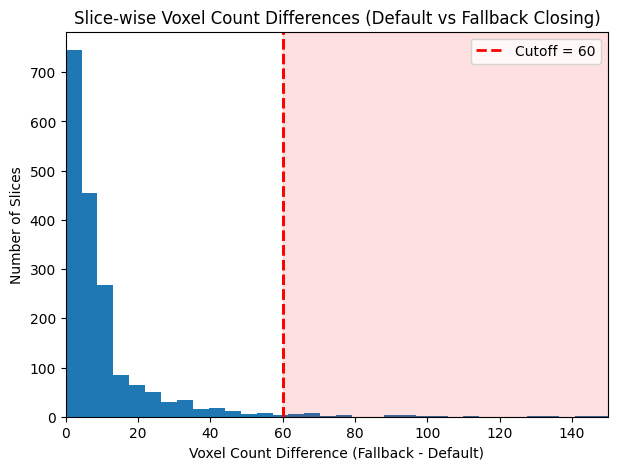

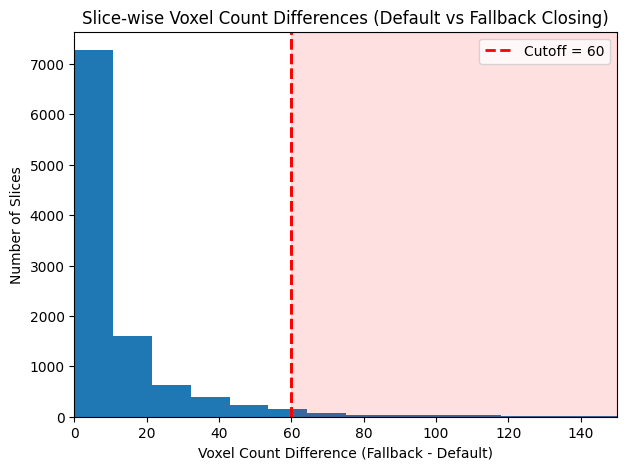

In [18]:
%matplotlib inline
metric = "diff_fallback_minus_cleaned"

for dataset_name, root_path in validation_dataset_paths.items():
    df_all_voxel_count_diffs = voxel_count_diffs_by_dataset[dataset_name]
    values = df_all_voxel_count_diffs[metric]

    plt.figure(figsize=(7, 5))
    plt.hist(values, bins=60)

    cutoff = 60
    plt.axvline(cutoff, color='red', linestyle='--', linewidth=2, label="Cutoff = 60")
    plt.axvspan(cutoff, 150, color='red', alpha=0.12)  

    plt.xlim(0, 150)   

    plt.title("Slice-wise Voxel Count Differences (Default vs Fallback Closing)")
    plt.xlabel("Voxel Count Difference (Fallback - Default)")
    plt.ylabel("Number of Slices")
    plt.legend()
    plt.axvline(60, color="red", linestyle="--", linewidth=2)
    plt.savefig(os.path.join(root_path, f"histogram_fallback.tiff"), format="tiff", dpi=600, bbox_inches="tight")
    plt.show()


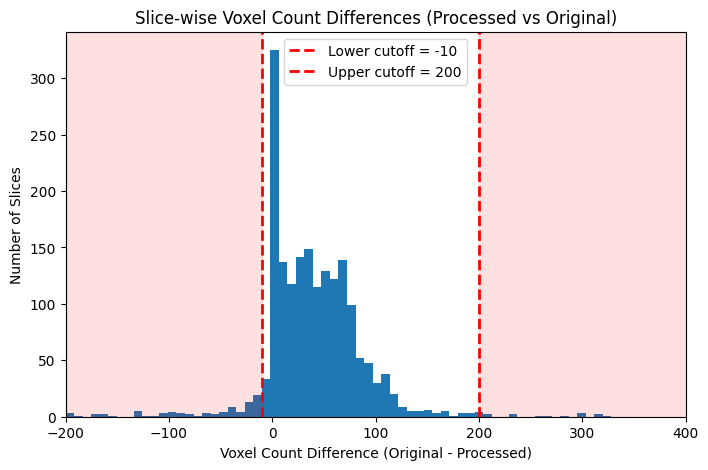

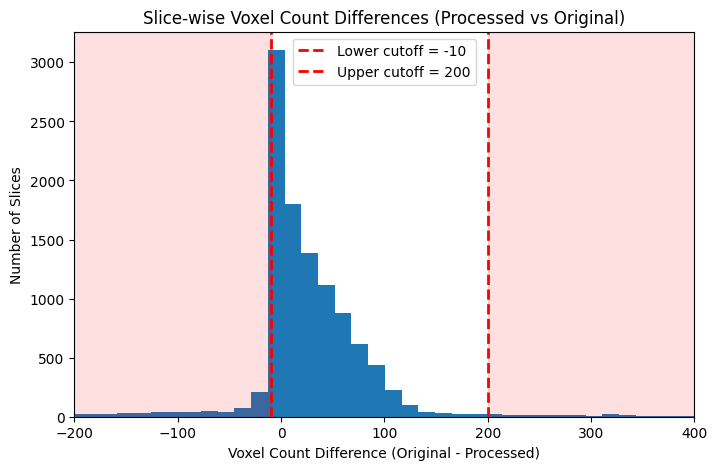

In [19]:
metric = "diff_original_minus_processed"

for dataset_name, root_path in validation_dataset_paths.items():
    df_all_voxel_count_diffs = voxel_count_diffs_by_dataset[dataset_name]
    values = df_all_voxel_count_diffs[metric]

    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=80)

    low_cut = -10
    high_cut = 200

    plt.axvline(low_cut, color='red', linestyle='--', linewidth=2, label="Lower cutoff = -10")
    plt.axvline(high_cut, color='red', linestyle='--', linewidth=2, label="Upper cutoff = 200")

    plt.axvspan(-200, low_cut, color='red', alpha=0.12)   
    plt.axvspan(high_cut, 400, color='red', alpha=0.12)   

    plt.xlim(-200, 400)

    plt.title("Slice-wise Voxel Count Differences (Processed vs Original)")
    plt.xlabel("Voxel Count Difference (Original - Processed)")
    plt.ylabel("Number of Slices")
    plt.legend()
    plt.savefig(os.path.join(root_path, f"histogram_processed.tiff"), format="tiff", dpi=600, bbox_inches="tight")
    plt.show()


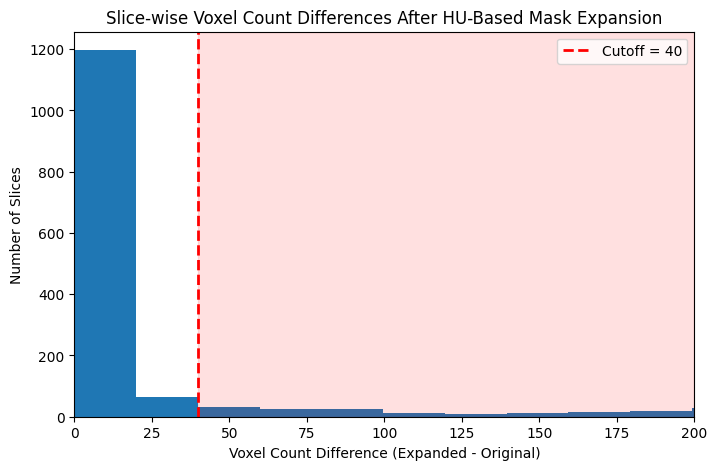

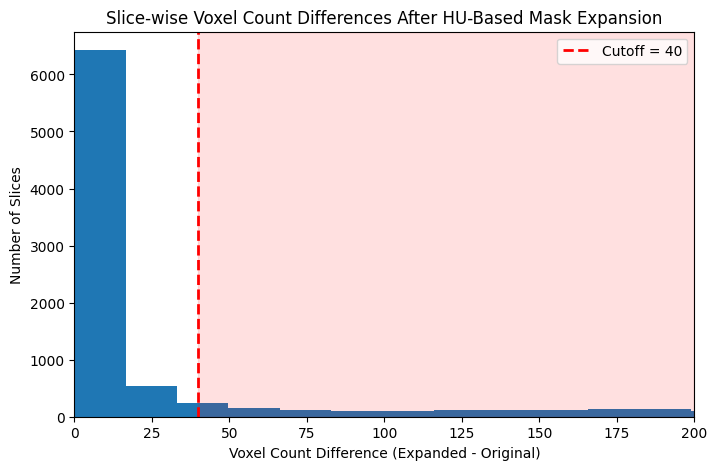

In [20]:
metric = "added_voxels"

for dataset_name, root_path in validation_dataset_paths.items():
    df_all_voxel_count_diffs = voxel_count_diffs_by_dataset[dataset_name]
    values = df_all_voxel_count_diffs[metric]

    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=60)

    high_cut = 40

    plt.axvline(high_cut, color='red', linestyle='--', linewidth=2, label="Cutoff = 40")
    plt.axvspan(high_cut, 200, color='red', alpha=0.12)

    plt.xlim(0, 200)

    plt.title("Slice-wise Voxel Count Differences After HU-Based Mask Expansion")
    plt.xlabel("Voxel Count Difference (Expanded - Original)")
    plt.ylabel("Number of Slices")
    plt.legend()
    plt.savefig(os.path.join(root_path, f"histogram_expanded.tiff"), format="tiff", dpi=600, bbox_inches="tight")
    plt.show()
